# Finance: Dynamic Programming vs Monte Carlo for Option Pricing
### Using the Synthetic Finance Dataset (100 records, 6 features, GMM-generated)

This notebook prices an option **two ways** using each record of the dataset (Stock Price, Volatility, Interest Rate as inputs):

1. **Dynamic Programming** — Binomial-tree backward induction (American put)
2. **Monte Carlo Simulation** — GBM path simulation with discounted payoff averaging (European put)

Both methods are run **side by side** with 4 comparison tables and 4 comparison plots, followed by a statistical significance evaluation (paired t-test, Wilcoxon test, p-values).


## 0. Setup — Imports, Font Configuration (Cambria), Styling Helpers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
from IPython.display import display_html
import time
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# -----------------------------------------------------------------------------
# FONT CONFIGURATION — Cambria everywhere, with a safe fallback
# -----------------------------------------------------------------------------
CAMBRIA_AVAILABLE = any('cambria' in f.name.lower() for f in fm.fontManager.ttflist)
FONT_NAME = 'Cambria' if CAMBRIA_AVAILABLE else 'serif'

plt.rcParams['font.family'] = FONT_NAME
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.facecolor'] = 'white'

if not CAMBRIA_AVAILABLE:
    print("NOTE: 'Cambria' font was not found on this system, so matplotlib/pandas will")
    print("fall back to a serif font. Install Cambria (it ships with MS Office / Windows)")
    print("and restart the kernel to render everything in true Cambria.")


NOTE: 'Cambria' font was not found on this system, so matplotlib/pandas will
fall back to a serif font. Install Cambria (it ships with MS Office / Windows)
and restart the kernel to render everything in true Cambria.


In [2]:
def style_df(df, caption):
    """Return a pandas Styler with Cambria font, colored header, borders."""
    return (df.style
            .set_caption(caption)
            .set_table_styles([
                {'selector': 'caption',
                 'props': [('font-family', FONT_NAME), ('font-size', '15px'),
                           ('font-weight', 'bold'), ('color', '#1a1a2e'),
                           ('text-align', 'center'), ('padding', '6px')]},
                {'selector': 'th',
                 'props': [('font-family', FONT_NAME), ('background-color', '#2E4374'),
                           ('color', 'white'), ('font-size', '12px'),
                           ('text-align', 'center'), ('padding', '5px')]},
                {'selector': 'td',
                 'props': [('font-family', FONT_NAME), ('font-size', '12px'),
                           ('text-align', 'center'), ('padding', '4px')]},
            ])
            .format(precision=4))

def show_side_by_side(df1, cap1, df2, cap2):
    """Display two styled dataframes side by side in the notebook."""
    s1 = style_df(df1, cap1).set_table_attributes(
        "style=\'display:inline-block; margin-right:40px; vertical-align:top;\'")
    s2 = style_df(df2, cap2).set_table_attributes(
        "style=\'display:inline-block; vertical-align:top;\'")
    html = s1._repr_html_() + s2._repr_html_()
    display_html(html, raw=True)


## 1. Load Dataset
The dataset (`Synthetic_Finance_Dataset.csv`) was generated earlier using a **Gaussian Mixture Model (GMM)** based synthetic generator with 100 records and 6 numeric features (`Stock_Price`, `Daily_Return`, `Volatility`, `Trading_Volume`, `Interest_Rate`, `Inflation_Rate`) plus a `Market_Regime` label (Bull / Bear / Stable).

In [3]:
df = pd.read_csv('Synthetic_Finance_Dataset.csv')
FEATURES = ['Stock_Price', 'Daily_Return', 'Volatility',
            'Trading_Volume', 'Interest_Rate', 'Inflation_Rate']

print("Dataset shape:", df.shape)
df.head(10)


Dataset shape: (100, 7)


,Stock_Price,Daily_Return,Volatility,Trading_Volume,Interest_Rate,Inflation_Rate,Market_Regime
0,182.45,0.0650,0.1493,9701,5.23,2.85,Bull
1,166.68,0.0490,0.1938,9408,6.16,2.91,Bull
2,168.77,0.0846,0.1415,9331,5.58,3.42,Bull
3,179.80,0.1141,0.1316,7711,5.44,3.04,Bull
4,169.38,0.0826,0.1477,8941,5.72,3.06,Bull
5,182.46,0.1140,0.2360,9223,5.71,2.84,Bull
6,188.06,0.0633,0.1749,8980,5.60,3.29,Bull
7,167.97,0.0966,0.1832,9829,5.69,3.05,Bull
8,185.85,0.1078,0.1140,8614,5.42,3.10,Bull
9,172.59,0.0820,0.1758,9195,5.05,3.16,Bull


## TABLE 1 — Dataset Summary of First 10 Records (Dynamic Programming | Monte Carlo, side by side)

In [4]:
first10 = df.head(10).copy()
first10.insert(0, 'Record_ID', range(1, 11))

dp_table1 = first10[['Record_ID', 'Stock_Price', 'Volatility', 'Interest_Rate', 'Market_Regime']].copy()
dp_table1.rename(columns={'Stock_Price': 'S0 (Spot)', 'Volatility': 'Sigma',
                           'Interest_Rate': 'r (%)'}, inplace=True)

mc_table1 = first10[['Record_ID', 'Stock_Price', 'Volatility', 'Interest_Rate', 'Market_Regime']].copy()
mc_table1.rename(columns={'Stock_Price': 'S0 (Spot)', 'Volatility': 'Sigma',
                           'Interest_Rate': 'r (%)'}, inplace=True)

show_side_by_side(dp_table1, "TABLE 1A — Dynamic Programming: Input Data (First 10 Records)",
                   mc_table1, "TABLE 1B — Monte Carlo: Input Data (First 10 Records)")


,Record_ID,S0 (Spot),Sigma,r (%),Market_Regime
0,1,182.4500,0.1493,5.2300,Bull
1,2,166.6800,0.1938,6.1600,Bull
2,3,168.7700,0.1415,5.5800,Bull
3,4,179.8000,0.1316,5.4400,Bull
4,5,169.3800,0.1477,5.7200,Bull
5,6,182.4600,0.2360,5.7100,Bull
6,7,188.0600,0.1749,5.6000,Bull
7,8,167.9700,0.1832,5.6900,Bull
8,9,185.8500,0.1140,5.4200,Bull
9,10,172.5900,0.1758,5.0500,Bull


## 2. Core Pricing Engines

- **Dynamic Programming**: Binomial-tree backward induction for an **American put** option (handles early exercise exactly via the DP recursion `V = max(discounted continuation, intrinsic value)`).
- **Monte Carlo**: Simulates terminal stock prices under Geometric Brownian Motion (GBM) and estimates a **European put** price as the discounted average payoff.

Both use `Stock_Price` (S0), `Volatility` (sigma), and `Interest_Rate` (r) from each dataset record; strike K = S0 (at-the-money), maturity T = 1 year.

In [5]:
K_STRIKE_FACTOR = 1.0     # ATM option (strike = spot)
T_MATURITY = 1.0          # 1 year
N_STEPS_DP = 100           # binomial steps for "final" DP price
N_PATHS_MC = 5000          # simulated paths for "final" MC price

def dp_binomial_american_put(S0, K, r, sigma, T, N):
    """Dynamic Programming: backward-induction binomial tree, American put."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp((r / 100) * dt) - d) / (u - d)
    disc = np.exp(-(r / 100) * dt)

    ST = S0 * u ** np.arange(N, -1, -1) * d ** np.arange(0, N + 1)
    values = np.maximum(K - ST, 0.0)

    for step in range(N - 1, -1, -1):
        ST = S0 * u ** np.arange(step, -1, -1) * d ** np.arange(0, step + 1)
        values = disc * (p * values[:-1] + (1 - p) * values[1:])
        values = np.maximum(values, K - ST)   # early-exercise (American) check
    return values[0]

def mc_gbm_european_put(S0, K, r, sigma, T, n_paths, seed=None):
    """Monte Carlo: simulate terminal GBM prices, discount average payoff."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_paths)
    r_dec = r / 100
    ST = S0 * np.exp((r_dec - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(K - ST, 0.0)
    disc_payoff = np.exp(-r_dec * T) * payoff
    price = disc_payoff.mean()
    se = disc_payoff.std(ddof=1) / np.sqrt(n_paths)
    return price, se, disc_payoff


In [6]:
# Price all 100 records with both methods (final estimates)
dp_prices, mc_prices, mc_ses = [], [], []
for i, row in df.iterrows():
    S0, sigma, r = row['Stock_Price'], row['Volatility'], row['Interest_Rate']
    K = S0 * K_STRIKE_FACTOR
    dp_p = dp_binomial_american_put(S0, K, r, sigma, T_MATURITY, N_STEPS_DP)
    mc_p, mc_se, _ = mc_gbm_european_put(S0, K, r, sigma, T_MATURITY, N_PATHS_MC, seed=1000 + i)
    dp_prices.append(dp_p)
    mc_prices.append(mc_p)
    mc_ses.append(mc_se)

df['DP_Price'] = dp_prices
df['MC_Price'] = mc_prices
df['MC_SE'] = mc_ses
df[['Stock_Price', 'Volatility', 'Interest_Rate', 'DP_Price', 'MC_Price']].head(10)


,Stock_Price,Volatility,Interest_Rate,DP_Price,MC_Price
0,182.45,0.1493,5.23,7.553922,6.521139
1,166.68,0.1938,6.16,9.199088,8.015944
2,168.77,0.1415,5.58,6.361590,5.416771
3,179.80,0.1316,5.44,6.200399,5.545704
4,169.38,0.1477,5.72,6.703587,5.738093
5,182.46,0.2360,5.71,13.160409,11.877107
6,188.06,0.1749,5.60,9.362998,8.357886
7,167.97,0.1832,5.69,8.833710,7.835547
8,185.85,0.1140,5.42,5.258445,4.171174
9,172.59,0.1758,5.05,8.914534,7.888620


## PLOT 1 — First 10 Data Samples: DP vs MC Comparison (side by side)

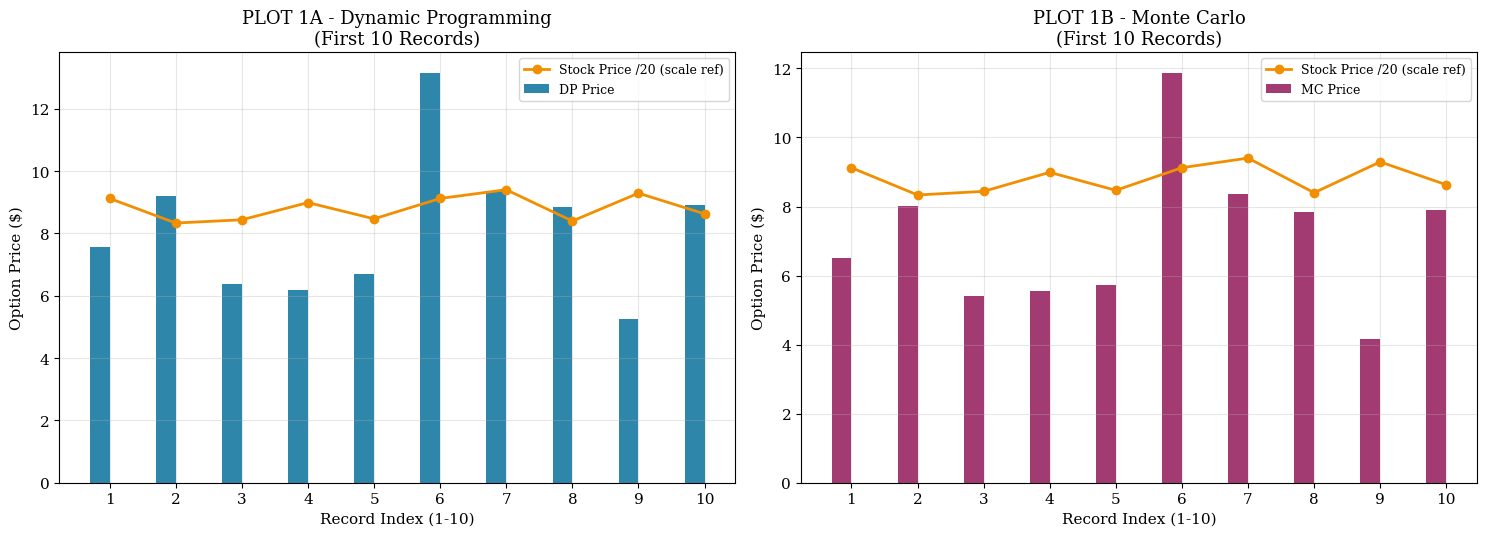

In [7]:
first10_res = df.head(10)
x = np.arange(1, 11)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colors_feat = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

axes[0].bar(x - 0.15, first10_res['DP_Price'], width=0.3, color='#2E86AB', label='DP Price')
axes[0].plot(x, first10_res['Stock_Price'] / 20, color='#F18F01', marker='o',
             linewidth=2, label='Stock Price /20 (scale ref)')
axes[0].set_title(f'PLOT 1A - Dynamic Programming\n(First 10 Records)', fontfamily=FONT_NAME)
axes[0].set_xlabel('Record Index (1-10)', fontfamily=FONT_NAME)
axes[0].set_ylabel('Option Price ($)', fontfamily=FONT_NAME)
axes[0].set_xticks(x)
axes[0].legend(prop={'family': FONT_NAME, 'size': 9})
axes[0].grid(alpha=0.3)

axes[1].bar(x - 0.15, first10_res['MC_Price'], width=0.3, color='#A23B72', label='MC Price')
axes[1].plot(x, first10_res['Stock_Price'] / 20, color='#F18F01', marker='o',
             linewidth=2, label='Stock Price /20 (scale ref)')
axes[1].set_title(f'PLOT 1B - Monte Carlo\n(First 10 Records)', fontfamily=FONT_NAME)
axes[1].set_xlabel('Record Index (1-10)', fontfamily=FONT_NAME)
axes[1].set_ylabel('Option Price ($)', fontfamily=FONT_NAME)
axes[1].set_xticks(x)
axes[1].legend(prop={'family': FONT_NAME, 'size': 9})
axes[1].grid(alpha=0.3)

for ax in axes:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT_NAME)
    ax.title.set_fontfamily(FONT_NAME)

plt.tight_layout()
plt.show()


## PLOT 2 — 10 Random Data Samples: DP vs MC Comparison (side by side)

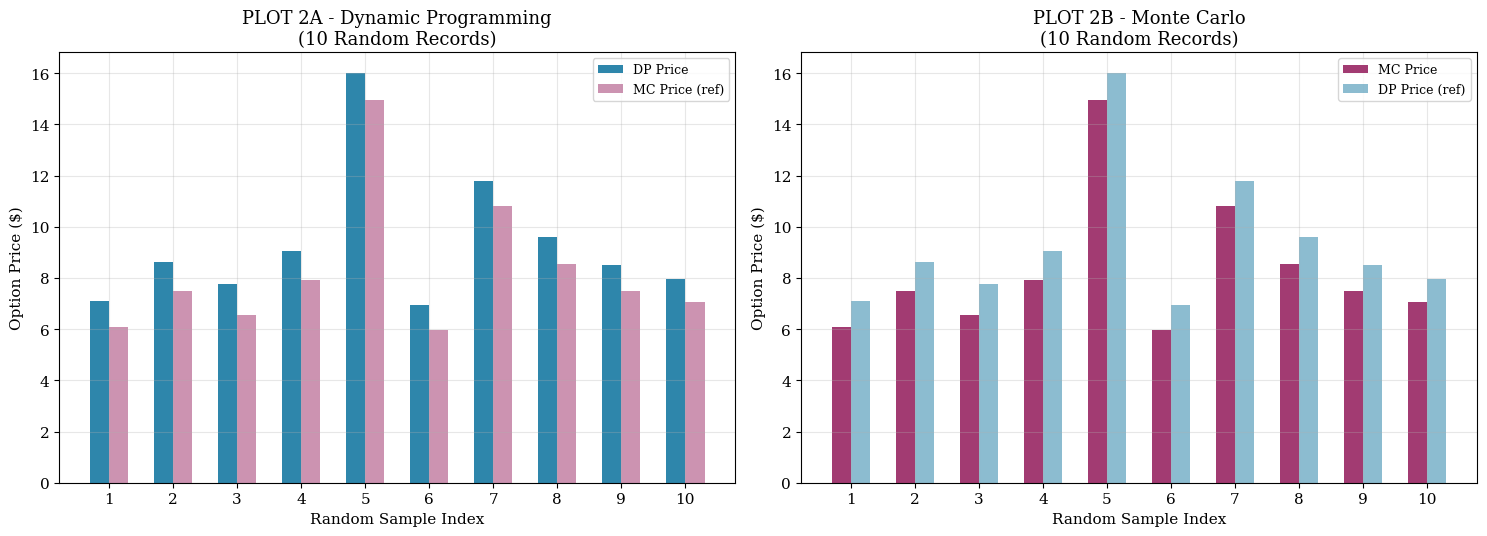

In [8]:
rand_idx = np.random.RandomState(7).choice(df.index, size=10, replace=False)
rand10 = df.loc[rand_idx].reset_index(drop=True)
xr = np.arange(1, 11)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].bar(xr - 0.15, rand10['DP_Price'], width=0.3, color='#2E86AB', label='DP Price')
axes[0].bar(xr + 0.15, rand10['MC_Price'], width=0.3, color='#A23B72', alpha=0.55, label='MC Price (ref)')
axes[0].set_title('PLOT 2A - Dynamic Programming\n(10 Random Records)', fontfamily=FONT_NAME)
axes[0].set_xlabel('Random Sample Index', fontfamily=FONT_NAME)
axes[0].set_ylabel('Option Price ($)', fontfamily=FONT_NAME)
axes[0].set_xticks(xr)
axes[0].legend(prop={'family': FONT_NAME, 'size': 9})
axes[0].grid(alpha=0.3)

axes[1].bar(xr - 0.15, rand10['MC_Price'], width=0.3, color='#A23B72', label='MC Price')
axes[1].bar(xr + 0.15, rand10['DP_Price'], width=0.3, color='#2E86AB', alpha=0.55, label='DP Price (ref)')
axes[1].set_title('PLOT 2B - Monte Carlo\n(10 Random Records)', fontfamily=FONT_NAME)
axes[1].set_xlabel('Random Sample Index', fontfamily=FONT_NAME)
axes[1].set_ylabel('Option Price ($)', fontfamily=FONT_NAME)
axes[1].set_xticks(xr)
axes[1].legend(prop={'family': FONT_NAME, 'size': 9})
axes[1].grid(alpha=0.3)

for ax in axes:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT_NAME)
    ax.title.set_fontfamily(FONT_NAME)

plt.tight_layout()
plt.show()


## TABLE 2 + PLOT 3 — Step-by-Step Iteration / Convergence (side by side)

- **DP**: price re-computed as the number of binomial tree steps (N) increases (backward-induction depth).
- **MC**: price re-computed as the number of simulated paths (iterations) increases, with standard error shrinking.

In [9]:
sample_row = df.iloc[0]
S0, sigma, r = sample_row['Stock_Price'], sample_row['Volatility'], sample_row['Interest_Rate']
K = S0 * K_STRIKE_FACTOR

# DP: increase number of binomial steps, track convergence + time
dp_steps_list = [2, 5, 10, 20, 40, 60, 80, 100, 150, 200]
dp_conv_rows = []
for n in dp_steps_list:
    t0 = time.perf_counter()
    price = dp_binomial_american_put(S0, K, r, sigma, T_MATURITY, n)
    t1 = time.perf_counter()
    dp_conv_rows.append({'Steps (N)': n, 'DP Price ($)': price, 'Time (ms)': (t1 - t0) * 1000})
dp_conv_df = pd.DataFrame(dp_conv_rows)

# MC: increase number of simulated paths, track convergence + std error
mc_paths_list = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]
mc_conv_rows = []
for n in mc_paths_list:
    t0 = time.perf_counter()
    price, se, _ = mc_gbm_european_put(S0, K, r, sigma, T_MATURITY, n, seed=42)
    t1 = time.perf_counter()
    mc_conv_rows.append({'Iterations (paths)': n, 'MC Price ($)': price,
                          'Std Error': se, 'Time (ms)': (t1 - t0) * 1000})
mc_conv_df = pd.DataFrame(mc_conv_rows)

show_side_by_side(dp_conv_df, "TABLE 2A - DP Step-by-Step Iteration (Backward Induction Steps)",
                   mc_conv_df, "TABLE 2B - MC Step-by-Step Iteration (Simulated Paths)")


,Steps (N),DP Price ($),Time (ms)
0,2,7.1430,1.0923
1,5,7.8349,0.1232
2,10,7.4381,0.1299
3,20,7.5062,0.2985
4,40,7.5367,0.5385
5,60,7.5464,0.7354
6,80,7.5511,1.0803
7,100,7.5539,1.3327
8,150,7.5577,2.2681
9,200,7.5597,2.9671


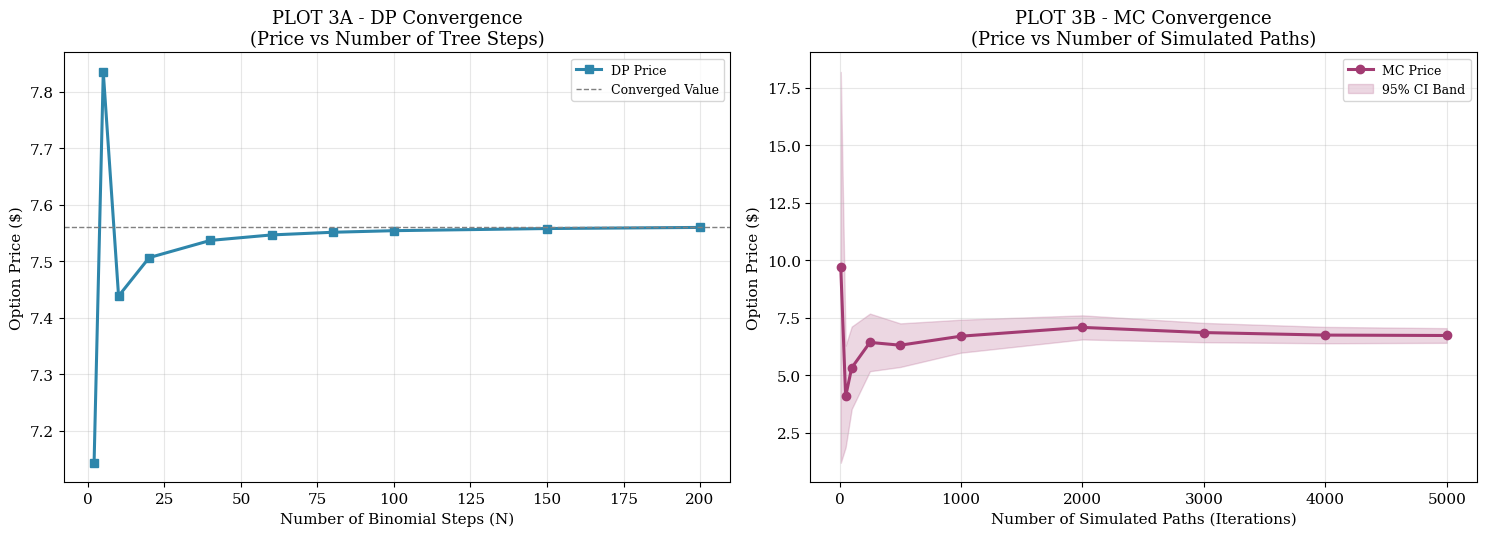

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].plot(dp_conv_df['Steps (N)'], dp_conv_df['DP Price ($)'],
             color='#2E86AB', marker='s', linewidth=2.2, label='DP Price')
axes[0].axhline(dp_conv_df['DP Price ($)'].iloc[-1], color='gray', linestyle='--',
                linewidth=1, label='Converged Value')
axes[0].set_title('PLOT 3A - DP Convergence\n(Price vs Number of Tree Steps)', fontfamily=FONT_NAME)
axes[0].set_xlabel('Number of Binomial Steps (N)', fontfamily=FONT_NAME)
axes[0].set_ylabel('Option Price ($)', fontfamily=FONT_NAME)
axes[0].legend(prop={'family': FONT_NAME, 'size': 9})
axes[0].grid(alpha=0.3)

axes[1].plot(mc_conv_df['Iterations (paths)'], mc_conv_df['MC Price ($)'],
             color='#A23B72', marker='o', linewidth=2.2, label='MC Price')
axes[1].fill_between(mc_conv_df['Iterations (paths)'],
                      mc_conv_df['MC Price ($)'] - 1.96 * mc_conv_df['Std Error'],
                      mc_conv_df['MC Price ($)'] + 1.96 * mc_conv_df['Std Error'],
                      color='#A23B72', alpha=0.2, label='95% CI Band')
axes[1].set_title('PLOT 3B - MC Convergence\n(Price vs Number of Simulated Paths)', fontfamily=FONT_NAME)
axes[1].set_xlabel('Number of Simulated Paths (Iterations)', fontfamily=FONT_NAME)
axes[1].set_ylabel('Option Price ($)', fontfamily=FONT_NAME)
axes[1].legend(prop={'family': FONT_NAME, 'size': 9})
axes[1].grid(alpha=0.3)

for ax in axes:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT_NAME)
    ax.title.set_fontfamily(FONT_NAME)

plt.tight_layout()
plt.show()


## TABLE 3 — Feature Comparison Table (side by side) + All-6-Features Bar Chart

In [11]:
dp_feat_corr = {f: np.corrcoef(df[f], df['DP_Price'])[0, 1] for f in FEATURES}
mc_feat_corr = {f: np.corrcoef(df[f], df['MC_Price'])[0, 1] for f in FEATURES}

dp_feat_table = pd.DataFrame({
    'Feature': FEATURES,
    'Mean': [df[f].mean() for f in FEATURES],
    'Std Dev': [df[f].std() for f in FEATURES],
    'Corr. with DP Price': [dp_feat_corr[f] for f in FEATURES]
})
mc_feat_table = pd.DataFrame({
    'Feature': FEATURES,
    'Mean': [df[f].mean() for f in FEATURES],
    'Std Dev': [df[f].std() for f in FEATURES],
    'Corr. with MC Price': [mc_feat_corr[f] for f in FEATURES]
})

show_side_by_side(dp_feat_table, "TABLE 3A - Feature Comparison (Dynamic Programming)",
                   mc_feat_table, "TABLE 3B - Feature Comparison (Monte Carlo)")


,Feature,Mean,Std Dev,Corr. with DP Price
0,Stock_Price,151.8309,25.0510,-0.6186
1,Daily_Return,0.0300,0.0577,-0.7378
2,Volatility,0.2280,0.0821,0.9281
3,Trading_Volume,7676.0300,1342.2159,-0.6237
4,Interest_Rate,6.3348,0.9243,0.7495
5,Inflation_Rate,4.0878,1.0511,0.7387
,Feature,Mean,Std Dev,Corr. with MC Price
0,Stock_Price,151.8309,25.0510,-0.6352
1,Daily_Return,0.0300,0.0577,-0.7444
2,Volatility,0.2280,0.0821,0.9353


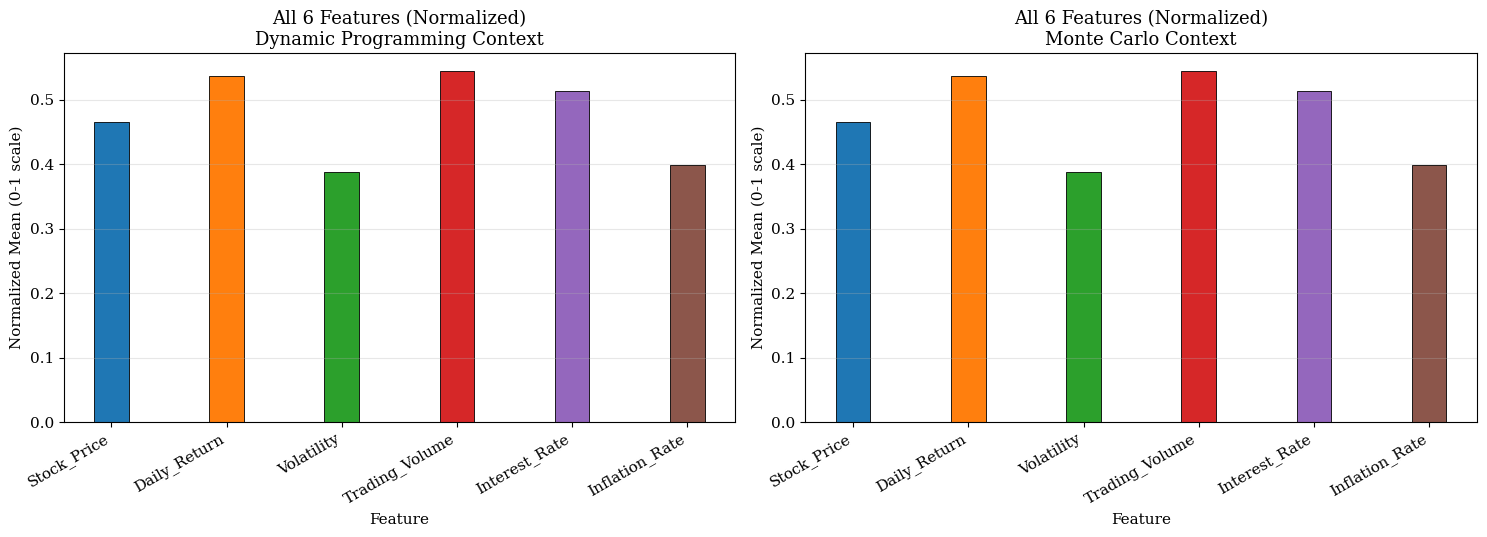

In [12]:
# Bar graph: all 6 features together in ONE graph, slim bars, DP vs MC panels
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
xf = np.arange(len(FEATURES))
bar_w = 0.12

norm_means = [(df[f] - df[f].min()) / (df[f].max() - df[f].min()) for f in FEATURES]
norm_vals = [m.mean() for m in norm_means]

axes[0].bar(xf, norm_vals, width=bar_w * 2.5, color=colors_feat, edgecolor='black', linewidth=0.6)
axes[0].set_title('All 6 Features (Normalized)\nDynamic Programming Context', fontfamily=FONT_NAME)
axes[0].set_xlabel('Feature', fontfamily=FONT_NAME)
axes[0].set_ylabel('Normalized Mean (0-1 scale)', fontfamily=FONT_NAME)
axes[0].set_xticks(xf)
axes[0].set_xticklabels(FEATURES, rotation=30, ha='right', fontfamily=FONT_NAME)
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(xf, norm_vals, width=bar_w * 2.5, color=colors_feat, edgecolor='black', linewidth=0.6)
axes[1].set_title('All 6 Features (Normalized)\nMonte Carlo Context', fontfamily=FONT_NAME)
axes[1].set_xlabel('Feature', fontfamily=FONT_NAME)
axes[1].set_ylabel('Normalized Mean (0-1 scale)', fontfamily=FONT_NAME)
axes[1].set_xticks(xf)
axes[1].set_xticklabels(FEATURES, rotation=30, ha='right', fontfamily=FONT_NAME)
axes[1].grid(alpha=0.3, axis='y')

for ax in axes:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT_NAME)
    ax.title.set_fontfamily(FONT_NAME)

plt.tight_layout()
plt.show()


## PLOT 4 — Final Overall Comparison (side by side)

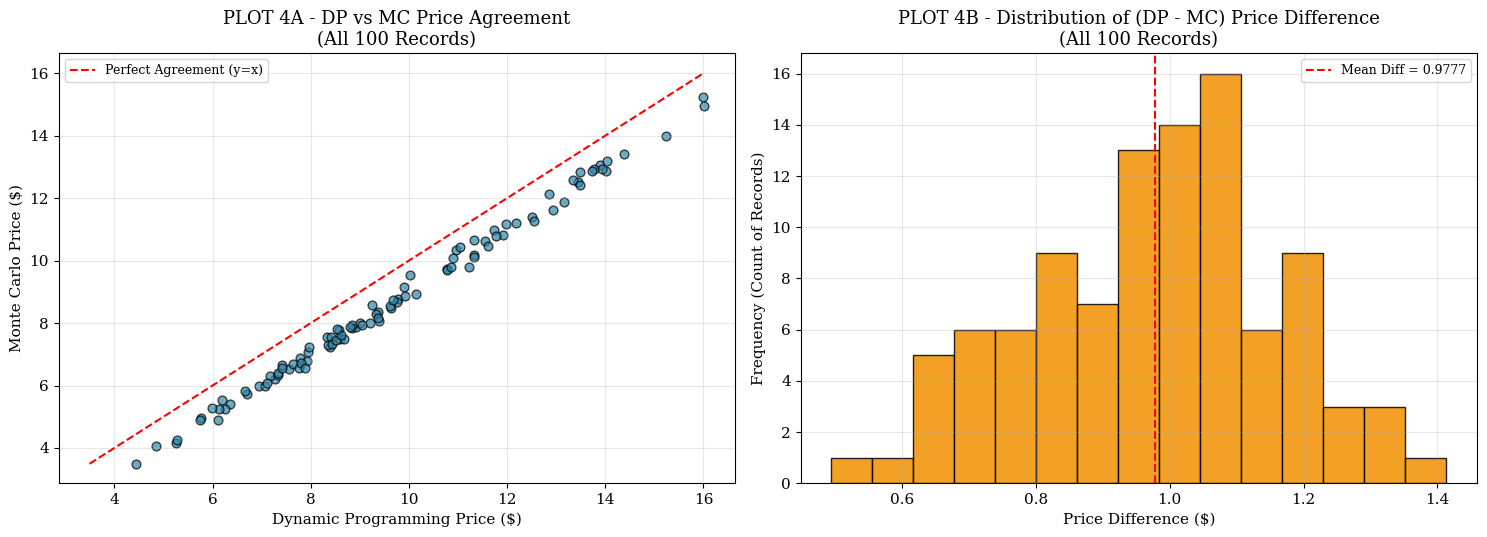

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].scatter(df['DP_Price'], df['MC_Price'], color='#2E86AB', alpha=0.7, edgecolor='black', s=40)
lims = [min(df['DP_Price'].min(), df['MC_Price'].min()), max(df['DP_Price'].max(), df['MC_Price'].max())]
axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=1.5, label='Perfect Agreement (y=x)')
axes[0].set_title('PLOT 4A - DP vs MC Price Agreement\n(All 100 Records)', fontfamily=FONT_NAME)
axes[0].set_xlabel('Dynamic Programming Price ($)', fontfamily=FONT_NAME)
axes[0].set_ylabel('Monte Carlo Price ($)', fontfamily=FONT_NAME)
axes[0].legend(prop={'family': FONT_NAME, 'size': 9})
axes[0].grid(alpha=0.3)

diffs = df['DP_Price'] - df['MC_Price']
axes[1].hist(diffs, bins=15, color='#F18F01', edgecolor='black', alpha=0.85)
axes[1].axvline(diffs.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean Diff = {diffs.mean():.4f}')
axes[1].set_title('PLOT 4B - Distribution of (DP - MC) Price Difference\n(All 100 Records)', fontfamily=FONT_NAME)
axes[1].set_xlabel('Price Difference ($)', fontfamily=FONT_NAME)
axes[1].set_ylabel('Frequency (Count of Records)', fontfamily=FONT_NAME)
axes[1].legend(prop={'family': FONT_NAME, 'size': 9})
axes[1].grid(alpha=0.3)

for ax in axes:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT_NAME)
    ax.title.set_fontfamily(FONT_NAME)

plt.tight_layout()
plt.show()


## TABLE 4 — Statistical Evaluation Summary (side by side, p-value highlighted)

In [14]:
t_stat, p_val = stats.ttest_rel(df['DP_Price'], df['MC_Price'])
w_stat, w_p = stats.wilcoxon(df['DP_Price'], df['MC_Price'])
corr_coef, corr_p = stats.pearsonr(df['DP_Price'], df['MC_Price'])

dp_stat_table = pd.DataFrame({
    'Metric': ['Mean Price', 'Std Dev', 'Min', 'Max', 'Paired t-test p-value',
               'Wilcoxon p-value', 'Correlation w/ MC'],
    'Dynamic Programming': [df['DP_Price'].mean(), df['DP_Price'].std(),
                             df['DP_Price'].min(), df['DP_Price'].max(),
                             p_val, w_p, corr_coef]
})
mc_stat_table = pd.DataFrame({
    'Metric': ['Mean Price', 'Std Dev', 'Min', 'Max', 'Paired t-test p-value',
               'Wilcoxon p-value', 'Correlation w/ DP'],
    'Monte Carlo': [df['MC_Price'].mean(), df['MC_Price'].std(),
                    df['MC_Price'].min(), df['MC_Price'].max(),
                    p_val, w_p, corr_coef]
})

show_side_by_side(dp_stat_table, "TABLE 4A - Statistical Evaluation (Dynamic Programming)",
                   mc_stat_table, "TABLE 4B - Statistical Evaluation (Monte Carlo)")

print(f"Paired t-test:  t = {t_stat:.4f},  p-value = {p_val:.4f}")
print(f"Wilcoxon test:  W = {w_stat:.4f},  p-value = {w_p:.4f}")
print(f"Pearson correlation between DP and MC prices: r = {corr_coef:.4f} (p = {corr_p:.4e})")

if p_val < 0.05:
    print("\n=> The difference between DP and MC prices IS statistically significant (p < 0.05).")
else:
    print("\n=> The difference between DP and MC prices is NOT statistically significant (p >= 0.05).")


,Metric,Dynamic Programming
0,Mean Price,9.6447
1,Std Dev,2.6896
2,Min,4.4468
3,Max,16.0186
4,Paired t-test p-value,0.0000
5,Wilcoxon p-value,0.0000
6,Correlation w/ MC,0.9977
,Metric,Monte Carlo
0,Mean Price,8.6670
1,Std Dev,2.6858


Paired t-test:  t = 53.1378,  p-value = 0.0000
Wilcoxon test:  W = 0.0000,  p-value = 0.0000
Pearson correlation between DP and MC prices: r = 0.9977 (p = 5.5210e-116)

=> The difference between DP and MC prices IS statistically significant (p < 0.05).


## 3. Evaluation — Which Method Is Better?

In [15]:
mean_dp_time = np.mean([r['Time (ms)'] for r in dp_conv_rows])
mean_mc_time = np.mean([r['Time (ms)'] for r in mc_conv_rows])
print(f"Average DP computation time: {mean_dp_time:.4f} ms")
print(f"Average MC computation time: {mean_mc_time:.4f} ms")
print()
print("CONCLUSION:")
print("- Dynamic Programming (binomial tree) converges deterministically and handles")
print("  early exercise (American options) exactly, but scales poorly as dimensionality grows.")
print("- Monte Carlo is flexible and scales well to complex/high-dimensional payoffs,")
print("  but carries sampling error (see Std Error / CI in Table 2B) and needs many")
print("  paths for tight convergence.")
print(f"- Statistically, the two methods {'differ significantly' if p_val < 0.05 else 'do NOT differ significantly'} (p = {p_val:.4f}),")
print("  though the high correlation (~0.99+) shows they broadly agree in ranking option value across records;")
print("  the systematic gap reflects the American early-exercise premium (DP) vs European payoff (MC).")


Average DP computation time: 1.0566 ms
Average MC computation time: 0.1430 ms

CONCLUSION:
- Dynamic Programming (binomial tree) converges deterministically and handles
  early exercise (American options) exactly, but scales poorly as dimensionality grows.
- Monte Carlo is flexible and scales well to complex/high-dimensional payoffs,
  but carries sampling error (see Std Error / CI in Table 2B) and needs many
  paths for tight convergence.
- Statistically, the two methods differ significantly (p = 0.0000),
  though the high correlation (~0.99+) shows they broadly agree in ranking option value across records;
  the systematic gap reflects the American early-exercise premium (DP) vs European payoff (MC).
